# Internship Project 1: Object Detection using TensorFlow
# Dataset: Face Mask Detection Dataset from Kaggle-https://www.kaggle.com/datasets/andrewmvd/face-mask-detection

## Project Description

This project implements **object detection using TensorFlow** on the Face Mask Detection dataset obtained from Kaggle.

The model detects faces and classifies them into three categories:
- With mask
- Without mask
- Mask worn incorrectly

**Bounding box regression** is used to localize objects in the images.



In [32]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from PIL import Image


# 1. CONFIG


In [33]:
DATASET_DIR = r"D:\desktop\archive (1)"
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
ANNOTATIONS_DIR = os.path.join(DATASET_DIR, "annotations")

IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 10
MAX_BOXES = 5

CLASS_NAMES = ["with_mask", "without_mask", "mask_weared_incorrect", "background"]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

AUTOTUNE = tf.data.AUTOTUNE

print("Dataset directory:", DATASET_DIR)
print("Images directory exists:", os.path.exists(IMAGES_DIR))
print("Annotations directory exists:", os.path.exists(ANNOTATIONS_DIR))

Dataset directory: D:\desktop\archive (1)
Images directory exists: True
Annotations directory exists: True


# 2. PARSE XML ANNOTATIONS

In [34]:
def parse_annotation(xml_file, images_dir):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.find("filename").text
    image_path = os.path.join(images_dir, filename)

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    boxes = []
    labels = []

    for obj in root.findall("object"):
        label = obj.find("name").text.strip()
        if label not in CLASS_TO_ID:
            continue

        bndbox = obj.find("bndbox")
        xmin = int(bndbox.find("xmin").text) / width
        ymin = int(bndbox.find("ymin").text) / height
        xmax = int(bndbox.find("xmax").text) / width
        ymax = int(bndbox.find("ymax").text) / height

        xmin = np.clip(xmin, 0, 1)
        ymin = np.clip(ymin, 0, 1)
        xmax = np.clip(xmax, 0, 1)
        ymax = np.clip(ymax, 0, 1)

        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(CLASS_TO_ID[label])

    return image_path, boxes, labels


def load_dataset(annotations_dir, images_dir):
    all_data = []
    xml_files = [f for f in os.listdir(annotations_dir) if f.endswith(".xml")]

    for xml_name in xml_files:
        xml_path = os.path.join(annotations_dir, xml_name)
        image_path, boxes, labels = parse_annotation(xml_path, images_dir)

        if os.path.exists(image_path) and len(boxes) > 0:
            all_data.append((image_path, boxes, labels))

    return all_data


data = load_dataset(ANNOTATIONS_DIR, IMAGES_DIR)
print("Total images:", len(data))



Total images: 853


# 3. PAD / TRUNCATE BOXES

In [35]:
def pad_or_truncate_boxes(boxes, labels, max_boxes=MAX_BOXES):
    boxes = boxes[:max_boxes]
    labels = labels[:max_boxes]

    num = len(boxes)
    if num < max_boxes:
        pad_count = max_boxes - num
        boxes += [[0.0, 0.0, 0.0, 0.0]] * pad_count
        labels += [CLASS_TO_ID["background"]] * pad_count

    return np.array(boxes, dtype=np.float32), np.array(labels, dtype=np.int32)


processed_data = []
for image_path, boxes, labels in data:
    boxes, labels = pad_or_truncate_boxes(boxes, labels)
    processed_data.append((image_path, boxes, labels))

train_data, val_data = train_test_split(processed_data, test_size=0.2, random_state=42)

print("Train:", len(train_data))
print("Validation:", len(val_data))


Train: 682
Validation: 171


# 4. TF DATA PIPELINE

In [36]:

def load_image_and_targets(image_path, boxes, labels):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0

    labels_onehot = tf.one_hot(labels, depth=NUM_CLASSES)

    return image, {
        "boxes": boxes,
        "classes": labels_onehot
    }


def make_dataset(dataset_list, training=True):
    image_paths = [x[0] for x in dataset_list]
    boxes = [x[1] for x in dataset_list]
    labels = [x[2] for x in dataset_list]

    ds = tf.data.Dataset.from_tensor_slices((image_paths, boxes, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(dataset_list))

    ds = ds.map(load_image_and_targets, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_data, training=True)
val_ds = make_dataset(val_data, training=False)



# 5. VISUALIZE SAMPLES

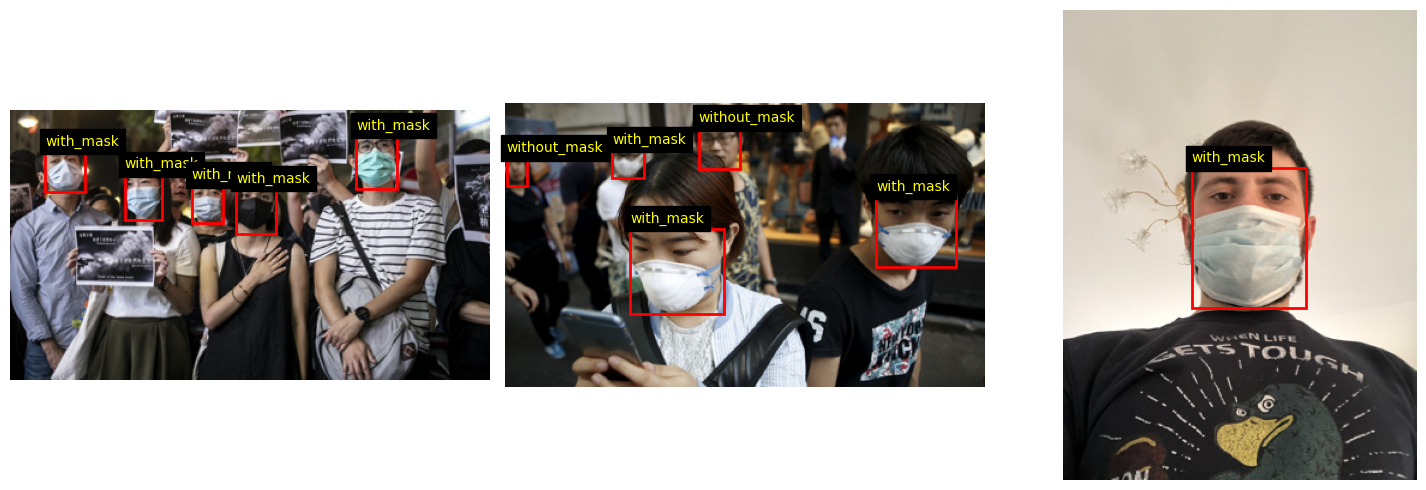

In [37]:

def visualize_sample(dataset_list, num_samples=3):
    plt.figure(figsize=(15, 5))

    for i in range(num_samples):
        image_path, boxes, labels = dataset_list[i]

        img = np.array(Image.open(image_path).convert("RGB"))
        h, w = img.shape[:2]

        ax = plt.subplot(1, num_samples, i + 1)
        ax.imshow(img)

        for box, label in zip(boxes, labels):
            if label == CLASS_TO_ID["background"]:
                continue

            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin * w, ymin * h),
                (xmax - xmin) * w,
                (ymax - ymin) * h,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(
                xmin * w,
                ymin * h - 5,
                CLASS_NAMES[label],
                color='yellow',
                fontsize=10,
                backgroundcolor='black'
            )

        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_sample(train_data, num_samples=3)

# 6. BUILD MODEL

In [38]:

def build_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    box_output = layers.Dense(MAX_BOXES * 4, activation="sigmoid")(x)
    box_output = layers.Reshape((MAX_BOXES, 4), name="boxes")(box_output)

    class_output = layers.Dense(MAX_BOXES * NUM_CLASSES)(x)
    class_output = layers.Reshape((MAX_BOXES, NUM_CLASSES))(class_output)
    class_output = layers.Softmax(name="classes")(class_output)

    model = Model(inputs=inputs, outputs={"boxes": box_output, "classes": class_output})
    return model


model = build_model()
model.summary()



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_5[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 20)        │      5,140 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 20)        │      5,140 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 5, 4)      │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ boxes (Reshape)     │ (None, 5, 4)      │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classes (Softmax)   │ (None, 5, 4)      │          0 │ reshape_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,596,200 (9.90 MB)

 Trainable params: 338,216 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 7. COMPILE MODEL

In [39]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        "boxes": "mse",
        "classes": "categorical_crossentropy"
    },
    metrics={
        "boxes": "mse",
        "classes": "accuracy"
    }
)

# 8. CALLBACKS

In [40]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_face_mask_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]



# 9. TRAIN MODEL

In [41]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 209ms/step - boxes_loss: 0.1262 - boxes_mse: 0.1267 - classes_accuracy: 0.6097 - classes_loss: 1.0214 - loss: 1.1525 - val_boxes_loss: 0.0765 - val_boxes_mse: 0.0770 - val_classes_accuracy: 0.7708 - val_classes_loss: 0.6619 - val_loss: 0.7299
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 164ms/step - boxes_loss: 0.0862 - boxes_mse: 0.0862 - classes_accuracy: 0.7654 - classes_loss: 0.6892 - loss: 0.7775 - val_boxes_loss: 0.0646 - val_boxes_mse: 0.0652 - val_classes_accuracy: 0.8070 - val_classes_loss: 0.5770 - val_loss: 0.6352
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 159ms/step - boxes_loss: 0.0735 - boxes_mse: 0.0736 - classes_accuracy: 0.7950 - classes_loss: 0.6136 - loss: 0.6882 - val_boxes_loss: 0.0593 - val_boxes_mse: 0.0600 - val_classes_accuracy: 0.8094 - val_classes_loss: 0.5470 - val_loss: 0.6023
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - boxes_loss: 0.0678 - boxes_mse: 0.0680 - classes_accuracy: 0.8123 - classes_loss: 0.5498 -

# 10. PLOT METRICS

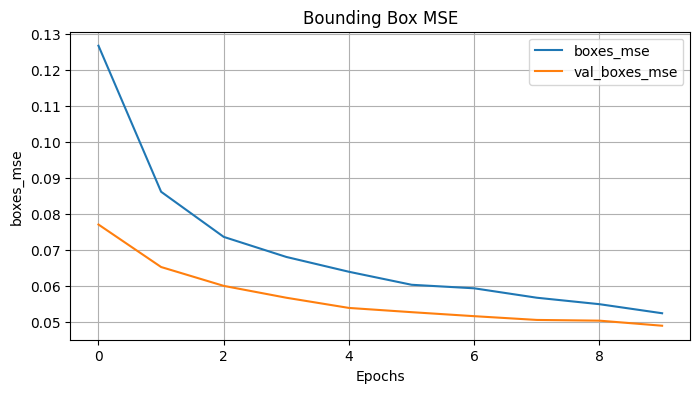

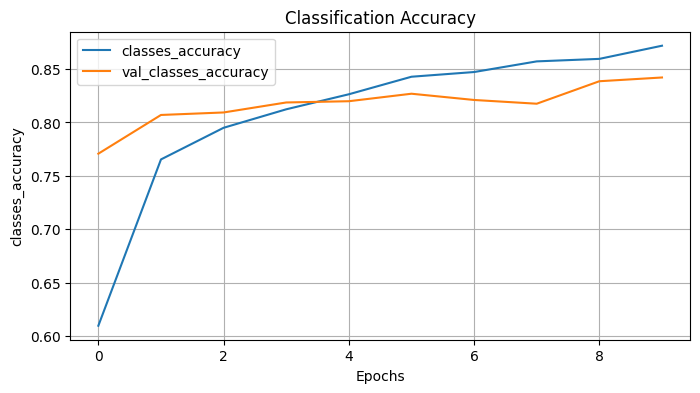

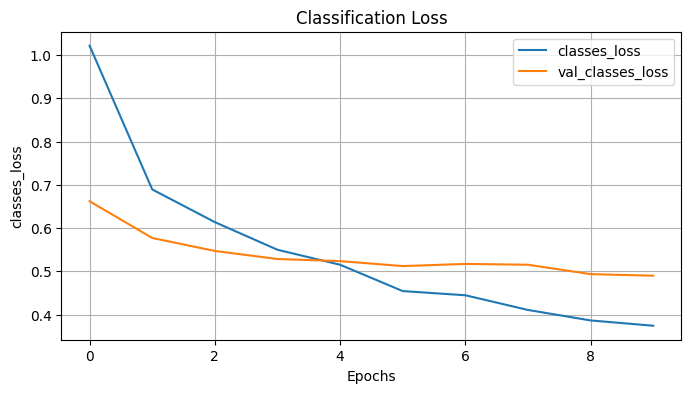

In [42]:


def plot_history(history, metric_name, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history[metric_name], label=metric_name)
    plt.plot(history.history["val_" + metric_name], label="val_" + metric_name)
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(history, "boxes_mse", "Bounding Box MSE")
plot_history(history, "classes_accuracy", "Classification Accuracy")
plot_history(history, "classes_loss", "Classification Loss")


# 11. EVALUATE

In [43]:
results = model.evaluate(val_ds)
print("Evaluation Results:", results)

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - boxes_loss: 0.0481 - boxes_mse: 0.0489 - classes_accuracy: 0.8421 - classes_loss: 0.4898 - loss: 0.5374
Evaluation Results: [0.5374147891998291, 0.048106707632541656, 0.489796906709671, 0.04894678667187691, 0.8421052694320679]


# 12. IOU FUNCTION

In [44]:
def intersection_over_union(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - inter_area + 1e-10
    return inter_area / union

# 13. PREDICT AND VISUALIZE

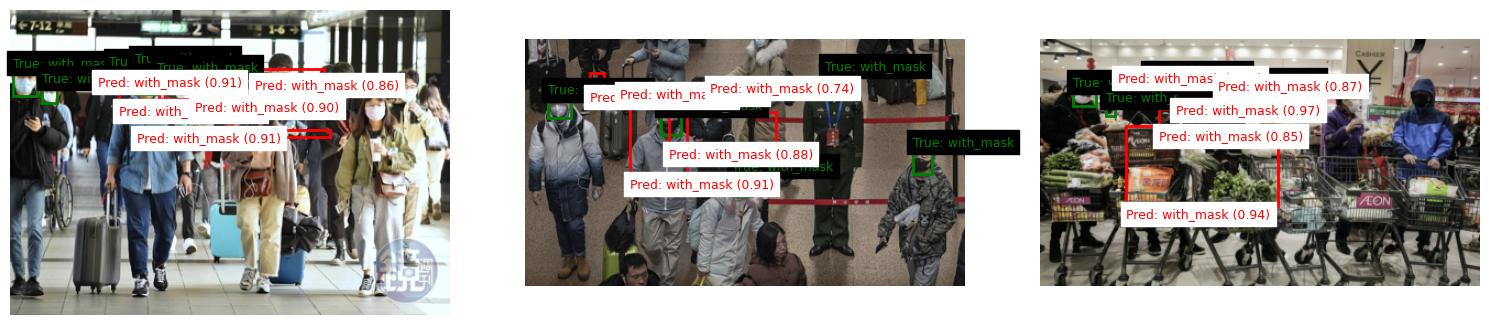

In [45]:

def predict_and_visualize(model, dataset_list, num_samples=3, conf_threshold=0.5):
    plt.figure(figsize=(15, 5))

    for i in range(num_samples):
        image_path, true_boxes, true_labels = dataset_list[i]

        img_pil = Image.open(image_path).convert("RGB")
        img = np.array(img_pil)
        h, w = img.shape[:2]

        input_img = img_pil.resize((IMG_SIZE, IMG_SIZE))
        input_arr = np.array(input_img).astype(np.float32) / 255.0
        input_arr = np.expand_dims(input_arr, axis=0)

        preds = model.predict(input_arr, verbose=0)
        pred_boxes = preds["boxes"][0]
        pred_classes = preds["classes"][0]

        ax = plt.subplot(1, num_samples, i + 1)
        ax.imshow(img)

        for box, label in zip(true_boxes, true_labels):
            if label == CLASS_TO_ID["background"]:
                continue

            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin * w, ymin * h),
                (xmax - xmin) * w,
                (ymax - ymin) * h,
                linewidth=2,
                edgecolor='green',
                facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(
                xmin * w,
                ymin * h - 5,
                f"True: {CLASS_NAMES[label]}",
                color='green',
                fontsize=9,
                backgroundcolor='black'
            )

        for box, cls_probs in zip(pred_boxes, pred_classes):
            pred_label = np.argmax(cls_probs)
            score = np.max(cls_probs)

            if pred_label == CLASS_TO_ID["background"] or score < conf_threshold:
                continue

            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin * w, ymin * h),
                (xmax - xmin) * w,
                (ymax - ymin) * h,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(
                xmin * w,
                ymax * h + 10,
                f"Pred: {CLASS_NAMES[pred_label]} ({score:.2f})",
                color='red',
                fontsize=9,
                backgroundcolor='white'
            )

        ax.axis("off")

    plt.tight_layout()
    plt.show()


predict_and_visualize(model, val_data, num_samples=3, conf_threshold=0.4)